# Day 02  Hiệu năng mô hình và so sánh ROI

[Open in Colab](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day02.ipynb)

[Slide của buổi này](_static/slides/day02_slides.pptx)

## Mục tiêu bài học

- Tạo pipeline logistic regression
- So sánh intra với ring1 ring3 ring5
- Đọc ROC AUC và confusion matrix
- Chọn ROI tốt nhất để mang sang Day 03

## Nội dung

Buổi này không cố làm nhiều mô hình.  
Chỉ dùng một pipeline rõ ràng để trả lời đúng câu hỏi của báo cáo:

ROI nào cho tín hiệu tốt hơn khi dự đoán EGFR

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def read_csv_demo(filename):
    local_candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ]
    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/{filename}"
    return pd.read_csv(url)


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 160
df = read_csv_demo("nsclc_egfr_radiomics_simplified.csv")
output_dir = Path("outputs/day02")
output_dir.mkdir(parents=True, exist_ok=True)


## Bước 1  Gom cột theo từng ROI


In [3]:
clinical_cols = ["age", "sex", "smoking_status", "histology", "stage", "tumor_size_mm", "tumor_volume_cm3", "tp53_mutation"]

feature_sets = {}
for name in ["intra", "ring1", "ring3", "ring5"]:
    feature_sets[name] = clinical_cols + [c for c in df.columns if c.startswith(name + "_")]

pd.DataFrame({
    "ROI": list(feature_sets.keys()),
    "So cot": [len(v) for v in feature_sets.values()]
})


,ROI,So cot
0,intra,15
1,ring1,13
2,ring3,13
3,ring5,13


## Bước 2  Viết pipeline

Pipeline có ba việc:

- điền giá trị thiếu
- chuẩn hoá biến số
- one hot cho biến phân loại
- logistic regression ở cuối


In [4]:
def make_pipe(X):
    cat = [c for c in X.columns if X[c].dtype == "object"]
    num = [c for c in X.columns if c not in cat]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat),
    ])

    return Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(max_iter=1000))
    ])


## Bước 3  Chạy một lần train test split cho từng ROI


In [5]:
y = df["egfr_mutation"].astype(int)
perf_rows = []
roc_store = {}

for name, cols in feature_sets.items():
    X = df[cols].copy()
    pipe = make_pipe(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, prob)
    cm = confusion_matrix(y_test, pred)
    sens = cm[1, 1] / cm[1].sum()
    spec = cm[0, 0] / cm[0].sum()
    fpr, tpr, _ = roc_curve(y_test, prob)

    perf_rows.append({
        "ROI": name,
        "AUC": round(auc, 3),
        "Sensitivity": round(sens, 3),
        "Specificity": round(spec, 3),
        "TN": int(cm[0, 0]),
        "FP": int(cm[0, 1]),
        "FN": int(cm[1, 0]),
        "TP": int(cm[1, 1]),
    })
    roc_store[name] = (fpr, tpr, cm)

perf_df = pd.DataFrame(perf_rows).sort_values("AUC", ascending=False)
perf_df.to_csv(output_dir / "roi_performance_table.csv", index=False)
perf_df


,ROI,AUC,Sensitivity,Specificity,TN,FP,FN,TP
1,ring1,0.815,0.391,0.778,21,6,14,9
2,ring3,0.747,0.522,0.852,23,4,11,12
3,ring5,0.747,0.435,0.815,22,5,13,10
0,intra,0.694,0.391,0.852,23,4,14,9


### Cách đọc bảng

Nếu chỉ nhìn bộ demo này thì ring1 đang đứng đầu.  
Đó là lý do Day 03 sẽ kiểm tra độ ổn định của ring1 kỹ hơn.


## Bước 4  Vẽ ROC để nhìn toàn cảnh


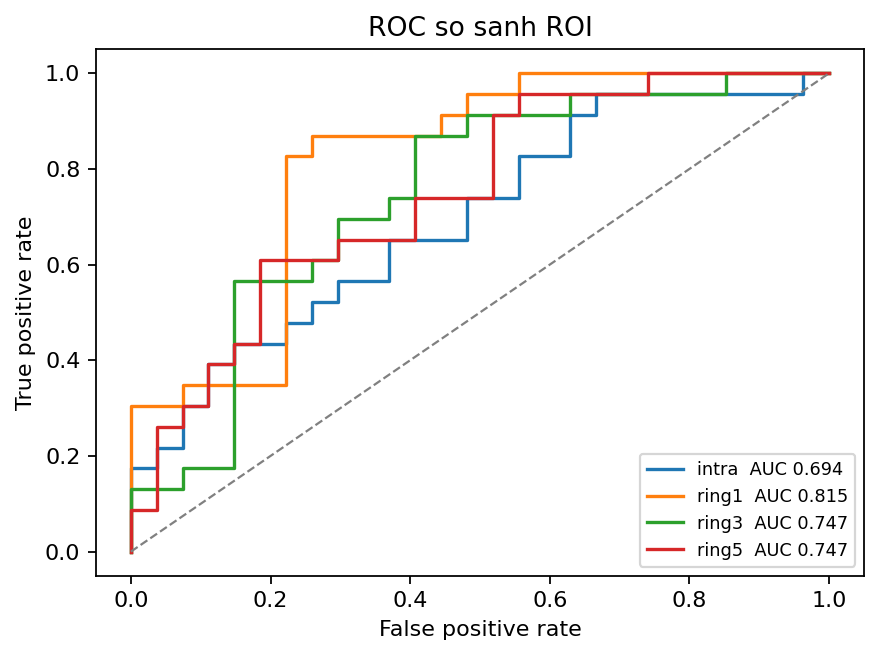

In [6]:
fig, ax = plt.subplots(figsize=(5.6, 4.2))
for name in ["intra", "ring1", "ring3", "ring5"]:
    X = df[feature_sets[name]].copy()
    pipe = make_pipe(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name}  AUC {auc:.3f}")

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_title("ROC so sanh ROI")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "roc_compare_roi.png")
plt.show()


## Bước 5  Vẽ confusion matrix cho ROI tốt nhất


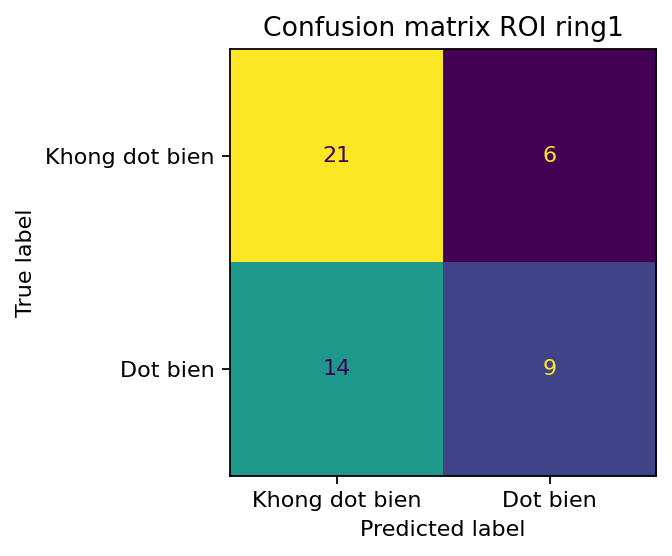

In [7]:
best_roi = perf_df.iloc[0]["ROI"]
best_cm = roc_store[best_roi][2]

fig, ax = plt.subplots(figsize=(4.1, 3.6))
ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=["Khong dot bien", "Dot bien"]
).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix ROI {best_roi}")
fig.tight_layout()
fig.savefig(output_dir / "confusion_best_roi.png")
plt.show()


## Bước 6  Viết ngắn kết quả của buổi 2


In [8]:
summary_day02 = (
    f"Trong lan chia minh hoa, ROI {perf_df.iloc[0]['ROI']} dat AUC {perf_df.iloc[0]['AUC']:.3f}. "
    f"ROI intra dat AUC {float(perf_df.loc[perf_df['ROI'] == 'intra', 'AUC'].iloc[0]):.3f}. "
    f"Vi vay ROI {perf_df.iloc[0]['ROI']} duoc chon de kiem tra do on dinh o Day 03."
)
summary_day02


'Trong lan chia minh hoa, ROI ring1 dat AUC 0.815. ROI intra dat AUC 0.694. Vi vay ROI ring1 duoc chon de kiem tra do on dinh o Day 03.'

## Tự kiểm tra

- Có hiểu đầu vào của pipeline là gì chưa
- Có hiểu AUC nói lên điều gì chưa
- Có biết vì sao confusion matrix và AUC phải đọc cùng nhau chưa
- Có lưu đủ bảng và hình chưa
